# Single molecule analysis
Set the identifier below and run all cells.

In [9]:
IDENTIFIER = 'XAPGUU'
CSV_FILE   = 'csd_all.csv'
CIF_OUTPUT = f'{IDENTIFIER}.cif'

In [10]:
import pandas as pd
from IPython.display import display
from rdkit import Chem
from rdkit.Chem import Draw
from ccdc import io

def fmt(val, unit='', decimals=None):
    if pd.isna(val):
        return 'N/A'
    if decimals is not None:
        return f'{val:.{decimals}f}{" " + unit if unit else ""}'
    return f'{val}{" " + unit if unit else ""}'

In [11]:
# Load CSV row
df  = pd.read_csv(CSV_FILE, low_memory=False)
row = df[df['identifier'] == IDENTIFIER]
if row.empty:
    raise ValueError(f"'{IDENTIFIER}' not found in {CSV_FILE}")
row = row.iloc[0]

# Load CSD entry
csd_reader = io.EntryReader('CSD')
entry = csd_reader.entry(IDENTIFIER)

print(f"Loaded: {IDENTIFIER}")

Loaded: XAPGUU


## 2D Structure

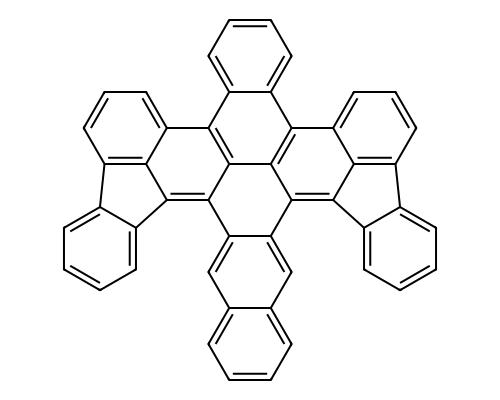

SMILES : c1ccc2cc3c(cc2c1)c1c2c4ccccc4c4cccc(c24)c2c4ccccc4c4c5cccc6c7ccccc7c(c56)c3c4c12
InChI  : InChI=1S/C48H24/c1-2-12-26-24-38-37(23-25(26)11-1)45-43-31-15-5-3-13-27(31)29-19-9-21-35(39(29)43)41-33-17-7-8-18-34(33)42-36-22-10-20-30-28-14-4-6-16-32(28)44(40(30)36)46(38)48(42)47(41)45/h1-24H


In [12]:
smiles = row['smiles']
rdmol  = Chem.MolFromSmiles(str(smiles)) if pd.notna(smiles) else None

if rdmol:
    display(Draw.MolToImage(rdmol, size=(500, 400)))
else:
    print('Could not parse SMILES.')

print(f'SMILES : {smiles}')
print(f'InChI  : {row["inchi"]}')

## Molecular properties

In [13]:
print(f'Identifier       : {row["identifier"]}')
print(f'CCDC number      : {fmt(row["ccdc_number"])}')
print(f'Molecular weight : {fmt(row["molecular_weight"], "g/mol", 3)}')
print(f'Molecular volume : {fmt(row["molecular_volume"], "Å³", 3)}')
print()
print(f'Is organic       : {row["is_organic"]}')
print(f'Has metal        : {row["has_metal"]}')
print(f'Has disorder     : {row["has_disorder"]}')
print(f'Num components   : {int(row["num_components"])}')
print()
print(f'Color            : {fmt(row["color"])}')
print(f'Solvent          : {fmt(row["solvent"])}')
print(f'Bioactivity      : {fmt(row["bioactivity"])}')
print(f'Polymorph        : {fmt(row["polymorph"])}')
print(f'Phase transition : {fmt(row["phase_transition"])}')

Identifier       : XAPGUU
CCDC number      : 2102025
Molecular weight : 600.703 g/mol
Molecular volume : 534.977 Å³

Is organic       : True
Has metal        : False
Has disorder     : True
Num components   : 1

Color            : yellow
Solvent          : N/A
Bioactivity      : N/A
Polymorph        : N/A
Phase transition : N/A


## Crystallographic info

In [14]:
print(f'Space group      : {row["spacegroup_symbol"]} (#{fmt(row["spacegroup_number"])}, setting {fmt(row["spacegroup_setting"])})')
print(f'Z / Z\'           : {fmt(row["z_value"])} / {fmt(row["z_prime"])}')
print()
print(f'Cell lengths     : a={fmt(row["cell_length_a"], "Å", 4)}  b={fmt(row["cell_length_b"], "Å", 4)}  c={fmt(row["cell_length_c"], "Å", 4)}')
print(f'Cell angles      : α={fmt(row["cell_angle_alpha"], "°", 3)}  β={fmt(row["cell_angle_beta"], "°", 3)}  γ={fmt(row["cell_angle_gamma"], "°", 3)}')
print(f'Cell volume      : {fmt(row["cell_volume"], "Å³", 3)}')
print(f'Density          : {fmt(row["calculated_density"], "g/cm³", 3)}')
print(f'R-factor         : {fmt(entry.r_factor, decimals=4)}')
print()
print(f'Temperature      : {fmt(row["temperature"])}  →  {fmt(row["temperature_K"], "K", 1)}')
print(f'Radiation source : {fmt(row["radiation_source"])}')
print(f'Melting point    : {fmt(row["melting_point"])}  →  {fmt(row["melting_point_k"], "K", 1)}')
print()
print(f'Deposition date  : {fmt(row["deposition_date"])}')
print(f'Publication year : {fmt(row["publication_years"])}')
print(f'DOI              : {fmt(row["doi"])}')
print()
ops = row["symmetry_operators"]
if pd.notna(ops):
    ops_list = str(ops).split('|')
    print(f'Symmetry operators ({len(ops_list)}):')
    for op in ops_list:
        print(f'  {op}')
else:
    print('Symmetry operators : N/A')

Space group      : C2/c (#15.0, setting 1.0)
Z / Z'           : 8.0 / 1.0

Cell lengths     : a=23.1160 Å  b=18.2730 Å  c=17.1540 Å
Cell angles      : α=90.000 °  β=90.060 °  γ=90.000 °
Cell volume      : 7245.823 Å³
Density          : 1.101 g/cm³
R-factor         : 12.7900

Temperature      : 193 K  →  193.0 K
Radiation source : Unknown
Melting point    : N/A  →  N/A

Deposition date  : 2021-11-20
Publication year : 2022.0
DOI              : 10.5517/ccdc.csd.cc28kb8g

Symmetry operators (8):
  x,y,z
  -x,y,1/2-z
  1/2+x,1/2+y,z
  1/2-x,1/2+y,1/2-z
  -x,-y,-z
  x,-y,1/2+z
  1/2-x,1/2-y,-z
  1/2+x,1/2-y,1/2+z


## Export CIF

In [15]:
with io.CrystalWriter(CIF_OUTPUT) as writer:
    writer.write(entry.crystal)
print(f'CIF exported to: {CIF_OUTPUT}')

CIF exported to: XAPGUU.cif
